Let's check if the conductance is continous as function of m,...

In [102]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous


# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
# create lattice
system_length = 15
lattice_type = "square"

lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])


# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 1  # Interaction strength
filling = 0.2  # filling of the lattice

/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_69247/1016669835.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


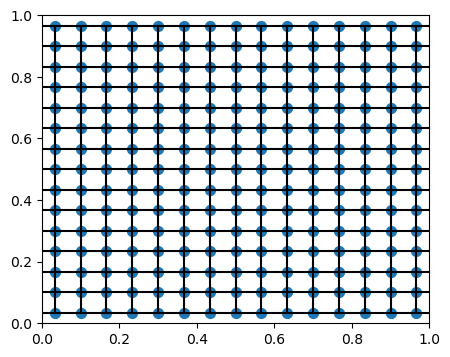

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

pl.plot_edges(lattice, ax=ax)
im = ax.scatter(
    lattice.vertices.positions[:, 0],
    lattice.vertices.positions[:, 1],
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)

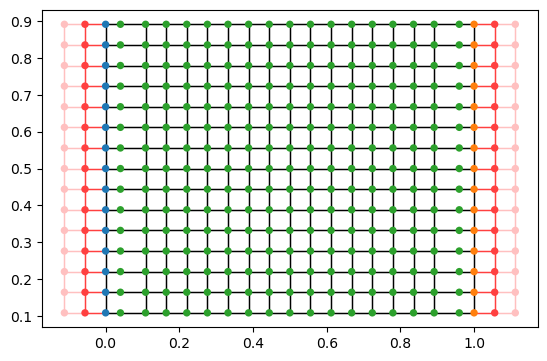

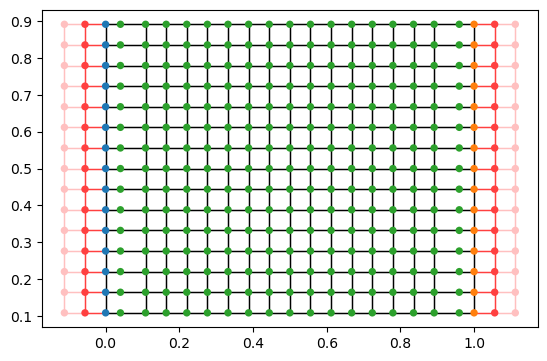

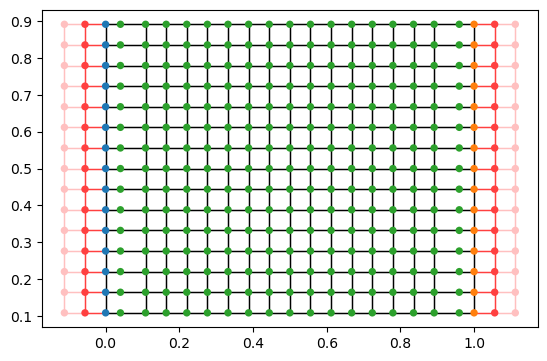

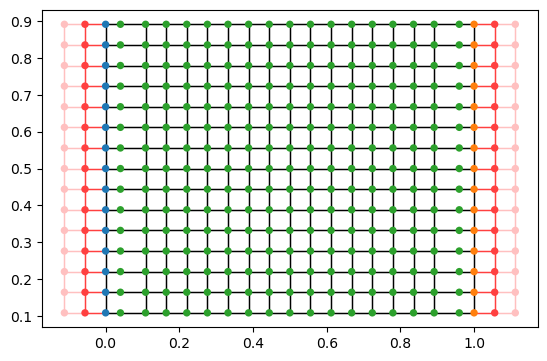

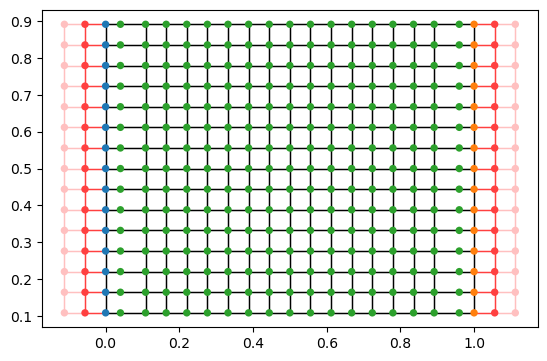

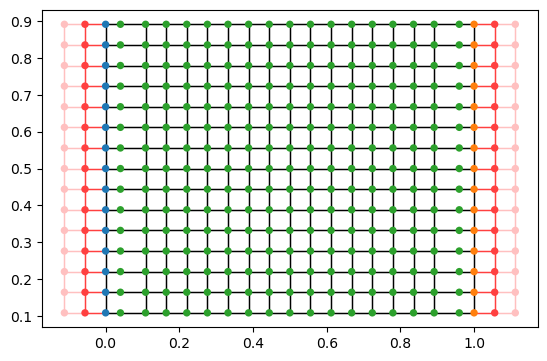

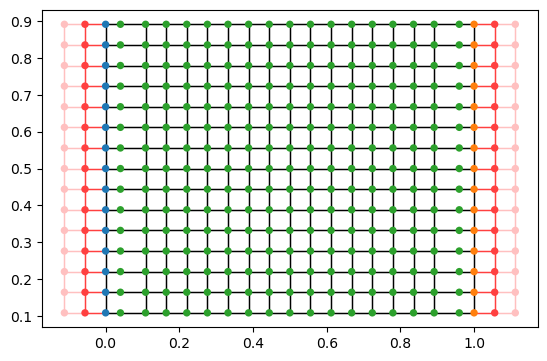

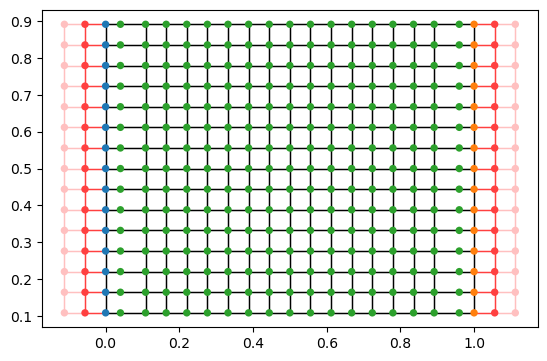

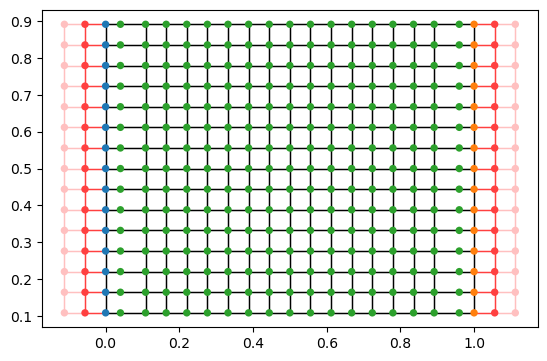

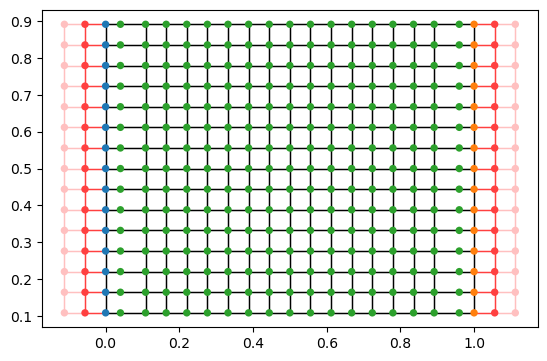

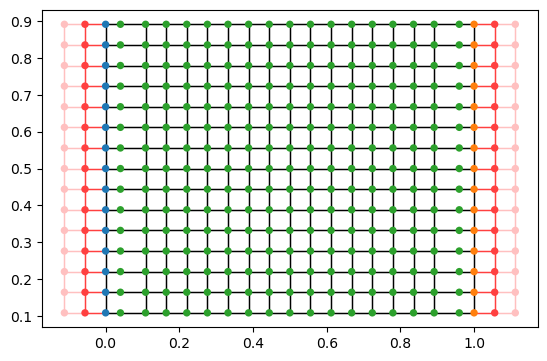

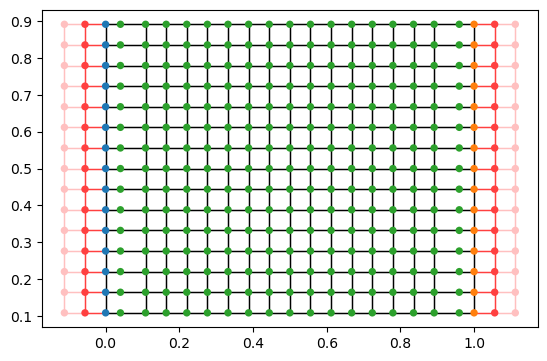

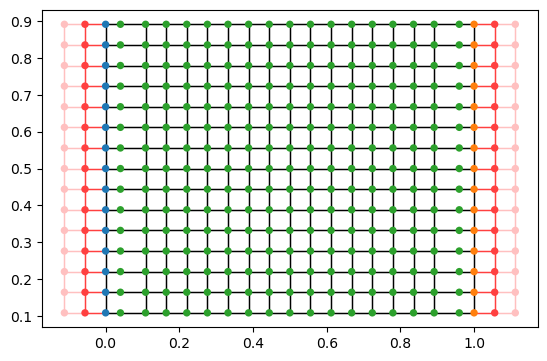

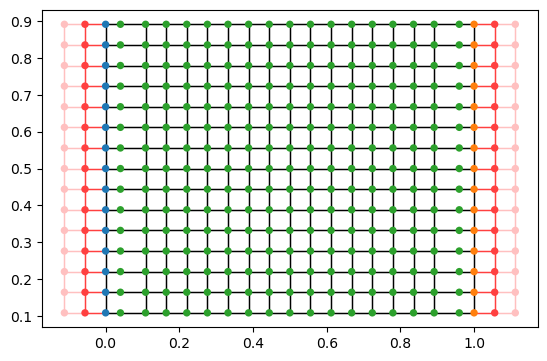

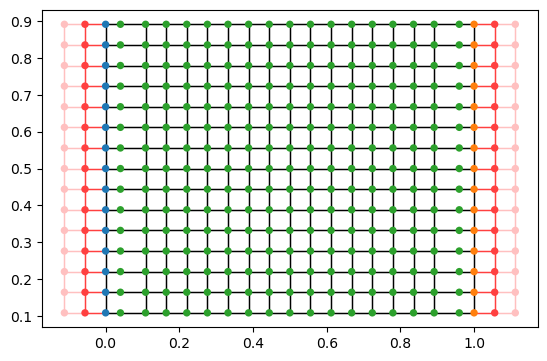

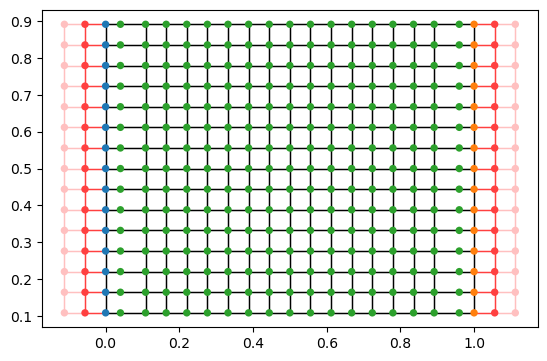

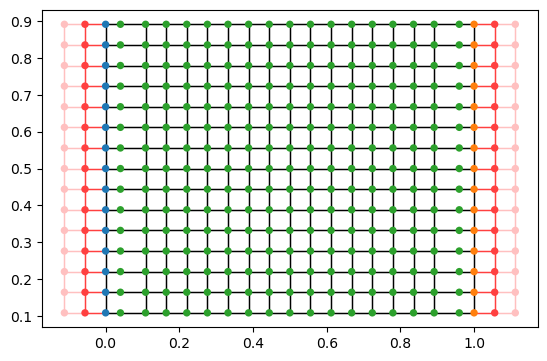

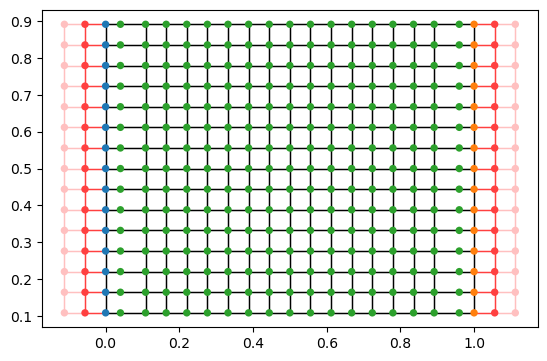

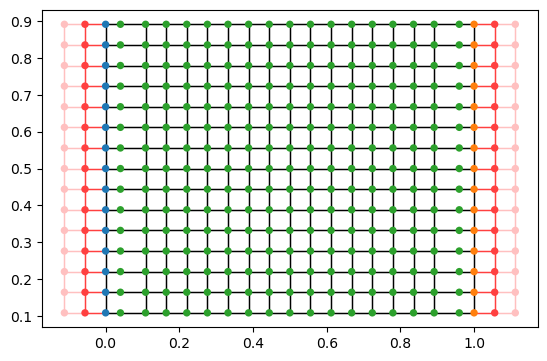

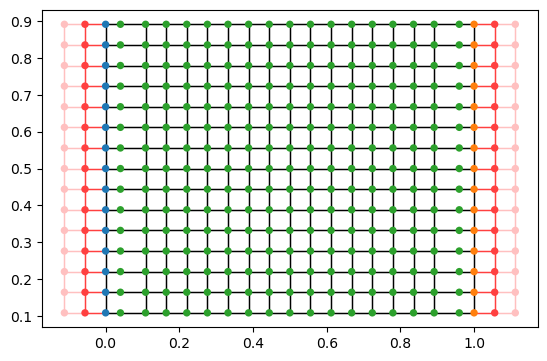

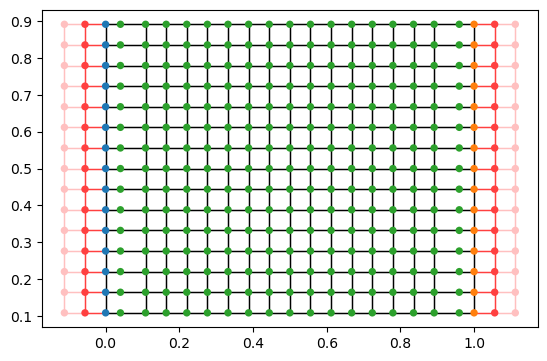

In [107]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)


conds = []; fermi_energies = []; cond_spins = []
ms = np.linspace(0,1,21)[:,np.newaxis] * np.ones((1,lattice.n_vertices))

for m in ms:

    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        J,
        m,
    )

    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[int(filling*len(energies))] #better algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, np.diag([-1,-1,1,1])
    )
    kwant.plot(kwant_system_with_leads)
    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f)#, energy=fermi_energy)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    
    conds.append(g[0,0]+g[1,1])
    cond_spins.append(g[0,0]-g[1,1])
    fermi_energies.append(fermi_energy)

conds = np.array(conds)
cond_spins = np.array(cond_spins)

10.041233109930802 9.356662834891853


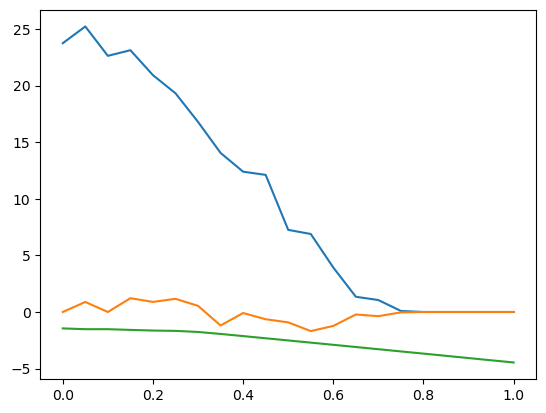

In [108]:
plt.plot(ms.mean(axis=-1),conds, "-")
plt.plot(ms.mean(axis=-1),cond_spins, "-")
plt.plot(ms.mean(axis=-1),fermi_energies, "-")

print(conds.mean(), conds.std())